In [ ]:
import wfdb 
import numpy as np
import pandas as pd

record_path = './mit-bih-arrhythmia-database-1.0.0/100'

# 데이터 읽기
record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, 'atr')

print(record)


df_signal = pd.DataFrame(record.p_signal, columns=record.sig_name)
df_signal['time(s)'] = np.arange(len(df_signal)) / record.fs
df_signal = df_signal[['time(s)'] + record.sig_name]

print(df_signal.head())

chid = 0
channel = record.p_signal[:, chid]
fs = record.fs  # 샘플링 주파수 (360Hz)
sig_name = record.sig_name[chid] # 채널 이름 (MLII)

print(f"ECG channel type: {sig_name}")
print(f"Sampling Frequency: {fs} Hz")

    time(s)   MLII     V5
0  0.000000 -0.145 -0.065
1  0.002778 -0.145 -0.065
2  0.005556 -0.145 -0.065
3  0.008333 -0.145 -0.065
4  0.011111 -0.145 -0.065
ECG channel type: MLII
Sampling Frequency: 360 Hz


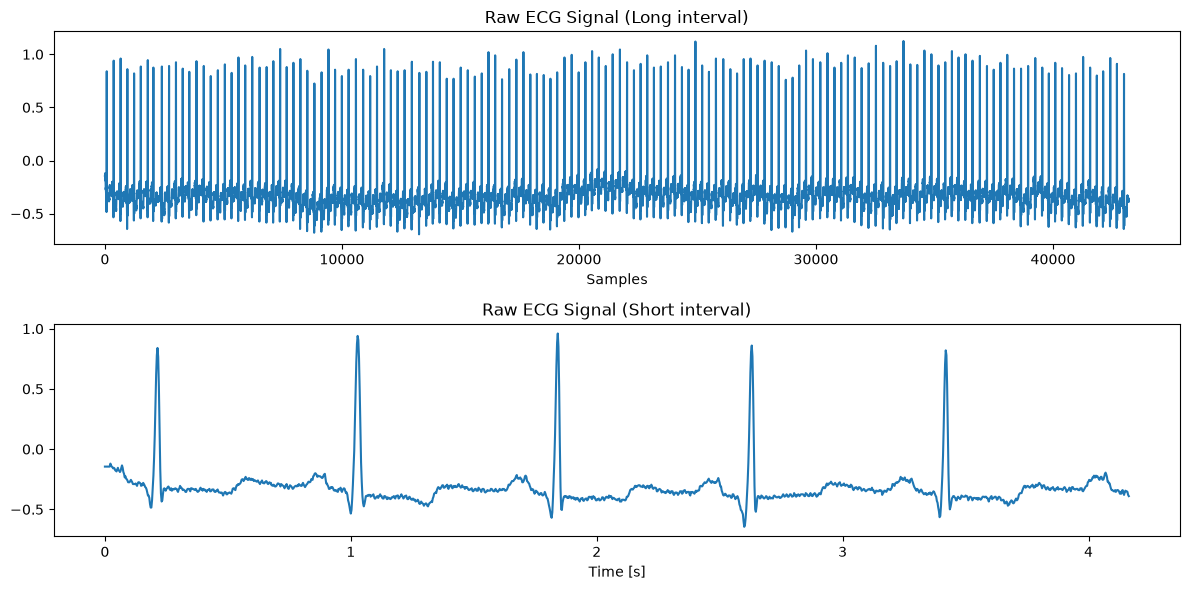

In [6]:
from matplotlib import pyplot as plt

duration = 1500
times = np.arange(duration, dtype='float') / fs

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(channel[:43200])
plt.title("Raw ECG Signal (Long interval)")
plt.xlabel("Samples")

plt.subplot(2, 1, 2)
plt.plot(times, channel[:duration])
plt.title("Raw ECG Signal (Short interval)")
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

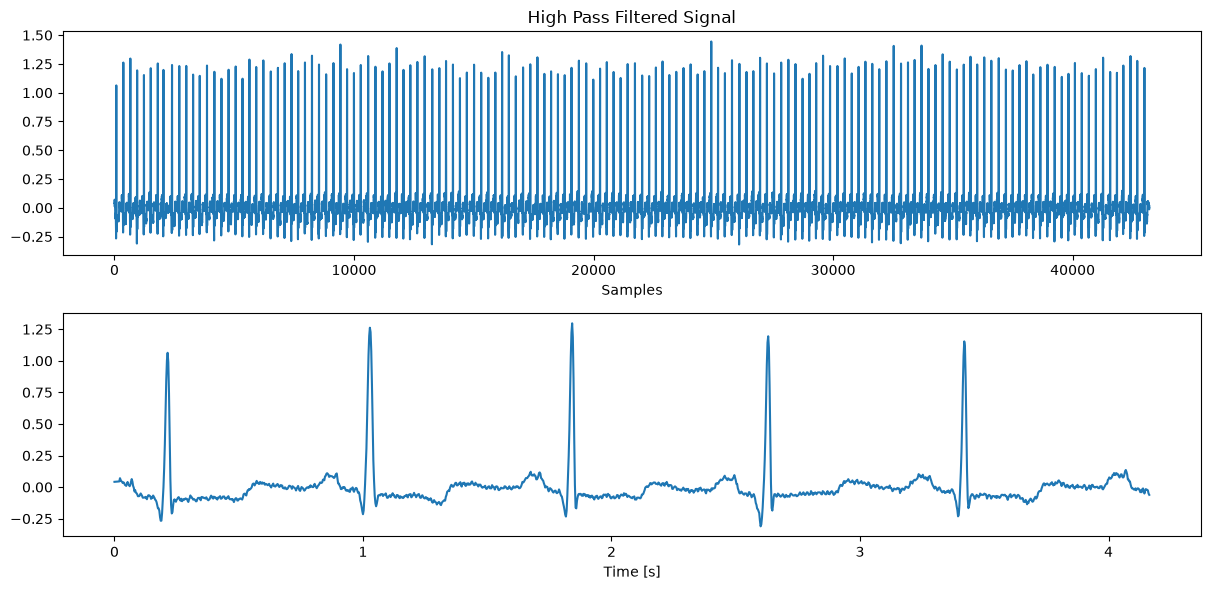

In [7]:
from scipy import signal

def high_pass_filter(signal_data, cut_off, sample_rate, order=5):
    # 최신 scipy.signal.butter 문법 (fs를 직접 입력)
    b, a = signal.butter(order, cut_off, btype='high', fs=sample_rate)
    out_data = signal.filtfilt(b, a, signal_data)
    return out_data

# 0.5Hz 이하의 저주파 성분(베이스라인 흔들림) 제거
HPF_signal = high_pass_filter(channel, cut_off=0.5, sample_rate=fs)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(HPF_signal[:43200])
plt.title("High Pass Filtered Signal")
plt.xlabel("Samples")

plt.subplot(2, 1, 2)
plt.plot(times, HPF_signal[:duration])
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

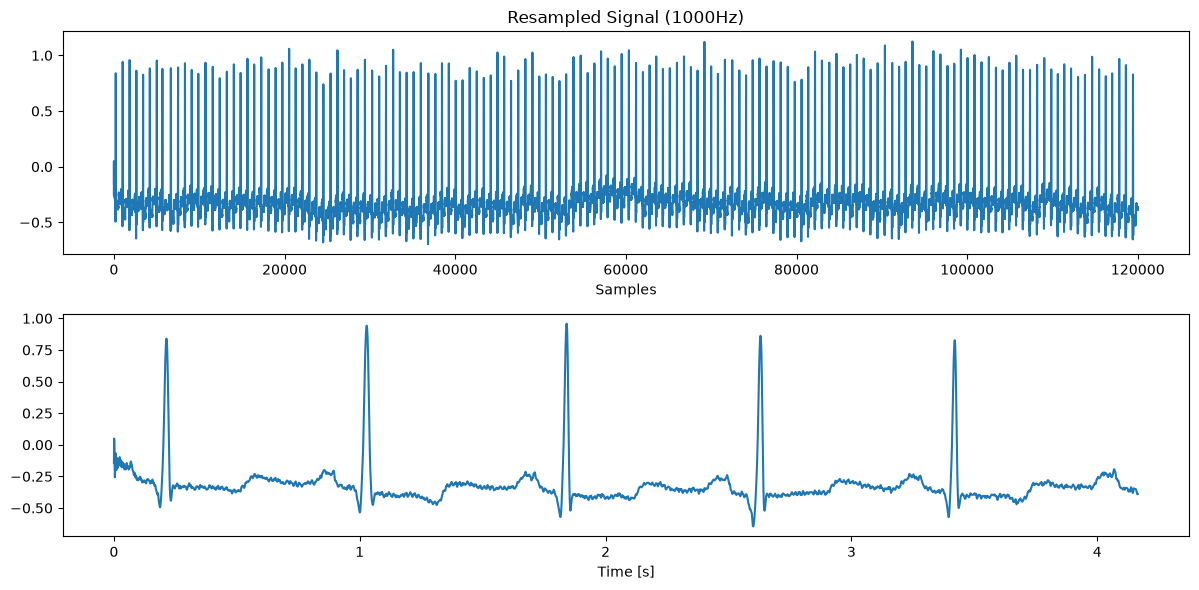

In [9]:
# 전체 신호의 시간 길이(초) 계산
sig_len = record.sig_len
sig_time_sec = sig_len / fs

# 1초에 1000개의 샘플이 되도록 타겟 샘플 수 계산
target_samples = int(sig_time_sec * 1000)

# 리샘플링 수행
resampled_signal = signal.resample(channel, target_samples)

duration_1000 = int(1500 * (1000 / 360)) # 비율에 맞춘 duration 조정
times_1000 = np.arange(duration_1000, dtype='float') / 1000

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(resampled_signal[:120000])
plt.title("Resampled Signal (1000Hz)")
plt.xlabel("Samples")

plt.subplot(2, 1, 2)
plt.plot(times_1000, resampled_signal[:duration_1000])
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

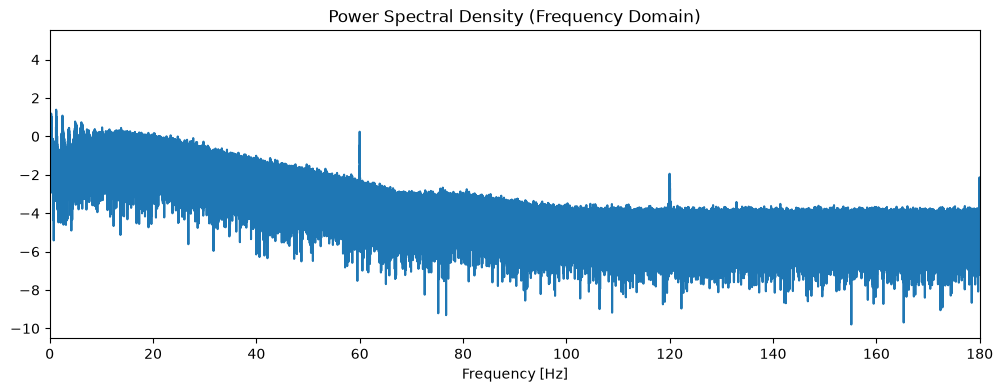

In [10]:
nfft = len(channel)

# numpy를 이용한 FFT 변환
FFT_ch1 = np.fft.fft(channel, nfft)

# 전력 스펙트럼 밀도(Power Spectral Density) 계산 (크기의 제곱)
PS_ch1 = np.abs(FFT_ch1)**2 / nfft

# 절반(양의 주파수 대역)만 사용
PSD_ch1 = PS_ch1[:int(nfft/2)]
f = fs * np.arange(nfft/2) / nfft

plt.figure(figsize=(12, 4))
# y축 로그 스케일 시 0이 되는 것을 방지하기 위해 미세한 값(1e-10) 추가
plt.plot(f, np.log10(PSD_ch1 + 1e-10))
plt.title("Power Spectral Density (Frequency Domain)")
plt.xlabel("Frequency [Hz]")
plt.xlim(0, 180) # Nyquist 주파수 (360/2)까지만 표시
plt.show()

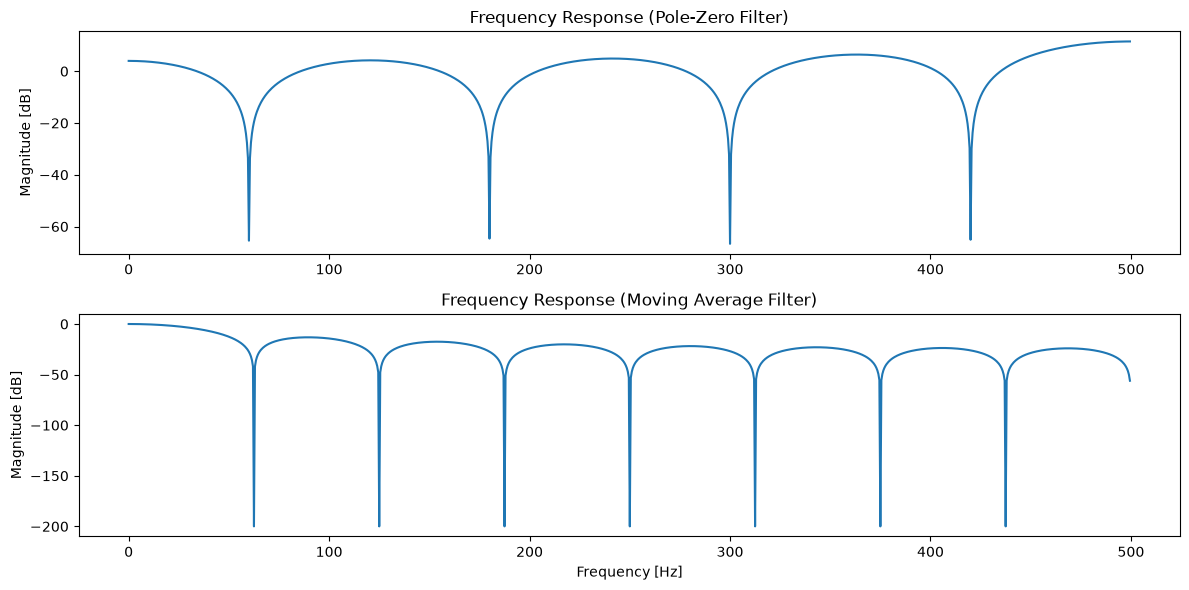

In [11]:
# 1. 60Hz 제거용 특정 Pole-Zero 설계 (Notch Filter 특성)
zer = [0.9297-1j*0.3681, 0.9297+1j*0.3681, 0.4257+1j*0.9048, 0.4257-1j*0.9048,
       -0.3090+1j*0.9510, -0.3090-1j*0.9510, -0.8763+1j*0.4817, -0.8763-1j*0.4817]

b, a = signal.zpk2tf(zer, [], 1)

# 2. 이동 평균(Moving Average) 필터 설계
bb = np.ones(16) / 16
aa = 1 # 분모 계수는 1

# 주파수 응답 계산 (샘플링 레이트를 1000Hz로 가정한 필터 평가)
w, h = signal.freqz(b, a, worN=1000, fs=1000)
ww, hh = signal.freqz(bb, aa, worN=1000, fs=1000)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
# np.abs()를 씌워 복소수 크기를 구한 뒤 log 변환 (경고 메시지 방지)
plt.plot(w, 20 * np.log10(np.abs(h) + 1e-10))
plt.title("Frequency Response (Pole-Zero Filter)")
plt.ylabel("Magnitude [dB]")

plt.subplot(2, 1, 2)
plt.plot(ww, 20 * np.log10(np.abs(hh) + 1e-10))
plt.title("Frequency Response (Moving Average Filter)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.tight_layout()
plt.show()

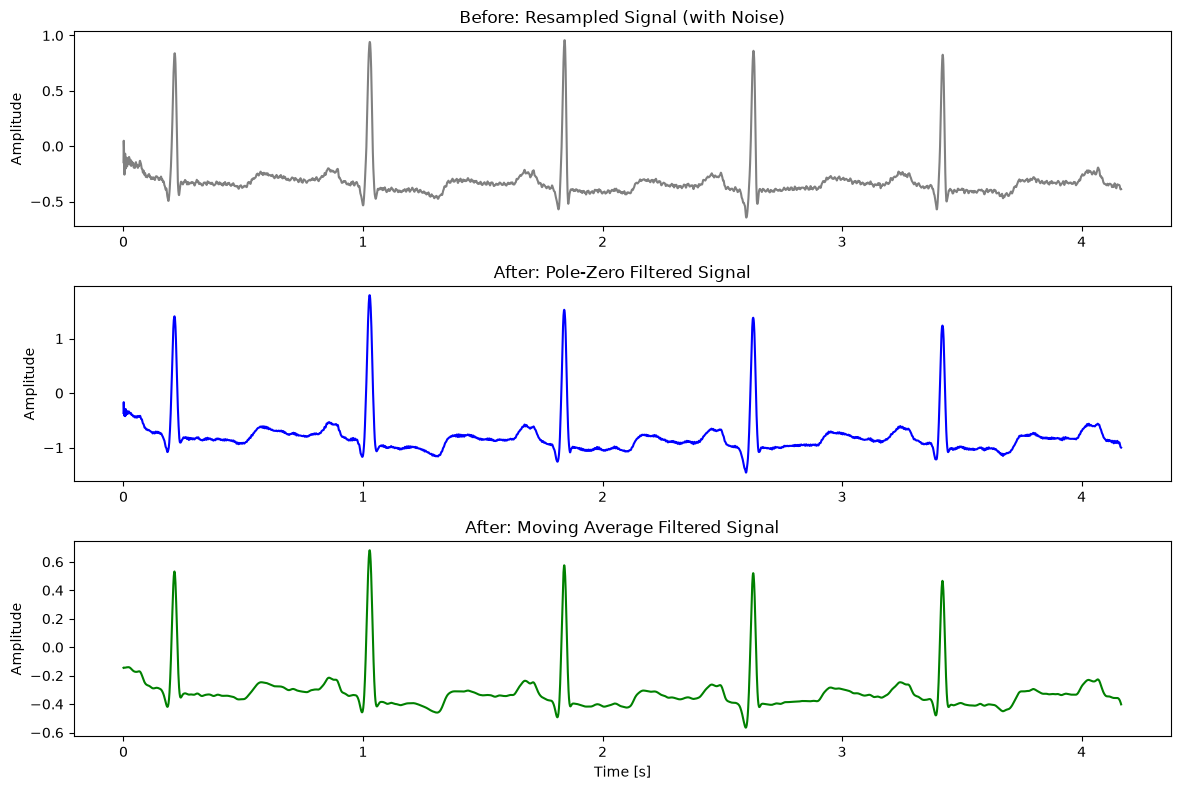

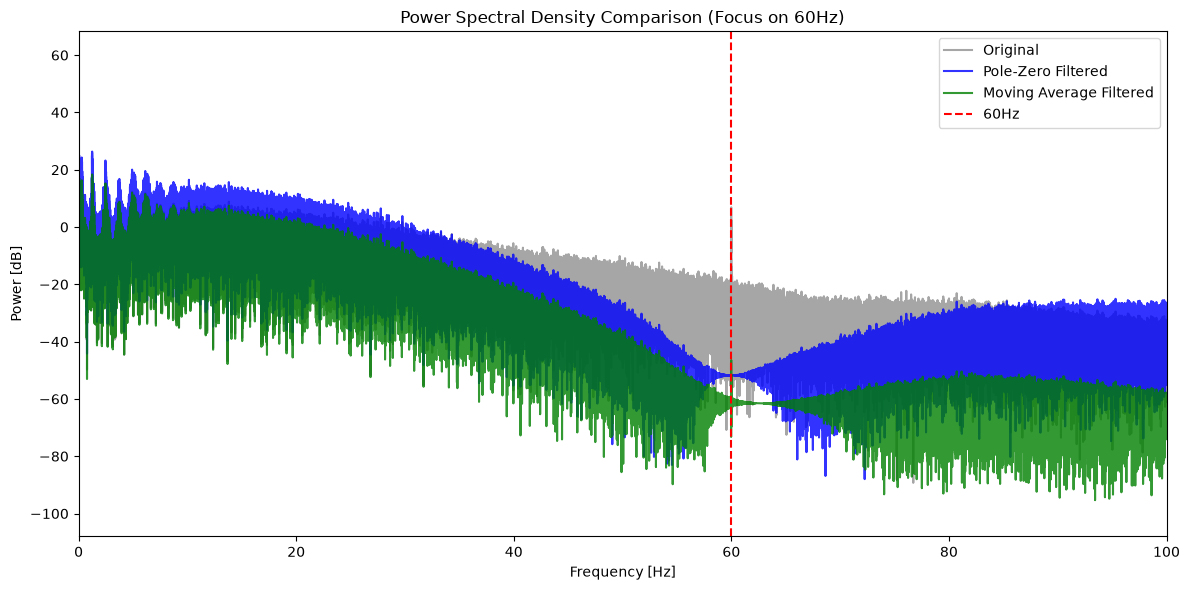

In [12]:
# 이전 코드에서 이어집니다. (resampled_signal, b, a, bb 변수 유지)

# 1. 필터 적용 (Zero-phase filtering)
# Pole-Zero 필터 적용
filtered_signal_pz = signal.filtfilt(b, a, resampled_signal)

# 이동 평균(Moving Average) 필터 적용 (bb를 1차원 배열로 변환하여 적용)
bb_flat = bb.flatten() 
filtered_signal_ma = signal.filtfilt(bb_flat, [1.0], resampled_signal)

# 2. 시간 영역(Time Domain) 파형 비교 시각화
duration_1000 = int(1500 * (1000 / 360))
times_1000 = np.arange(duration_1000, dtype='float') / 1000

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(times_1000, resampled_signal[:duration_1000], color='gray')
plt.title("Before: Resampled Signal (with Noise)")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.plot(times_1000, filtered_signal_pz[:duration_1000], color='blue')
plt.title("After: Pole-Zero Filtered Signal")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.plot(times_1000, filtered_signal_ma[:duration_1000], color='green')
plt.title("After: Moving Average Filtered Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# 3. 주파수 영역(Frequency Domain) 스펙트럼 비교 시각화
# 노이즈가 실제로 제거되었는지 FFT를 통해 확인합니다.
def get_psd(sig, fs=1000):
    nfft = len(sig)
    fft_vals = np.fft.fft(sig, nfft)
    psd = np.abs(fft_vals)**2 / nfft
    freqs = fs * np.arange(nfft//2) / nfft
    return freqs, psd[:nfft//2]

f, psd_original = get_psd(resampled_signal)
f, psd_pz = get_psd(filtered_signal_pz)
f, psd_ma = get_psd(filtered_signal_ma)

plt.figure(figsize=(12, 6))
# 60Hz 대역을 자세히 보기 위해 x축을 0~100Hz로 제한
plt.plot(f, 10 * np.log10(psd_original + 1e-10), label='Original', color='gray', alpha=0.7)
plt.plot(f, 10 * np.log10(psd_pz + 1e-10), label='Pole-Zero Filtered', color='blue', alpha=0.8)
plt.plot(f, 10 * np.log10(psd_ma + 1e-10), label='Moving Average Filtered', color='green', alpha=0.8)

plt.title("Power Spectral Density Comparison (Focus on 60Hz)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [dB]")
plt.xlim(0, 100) 
plt.axvline(x=60, color='red', linestyle='--', label='60Hz') # 60Hz 마커 라인
plt.legend()
plt.tight_layout()
plt.show()